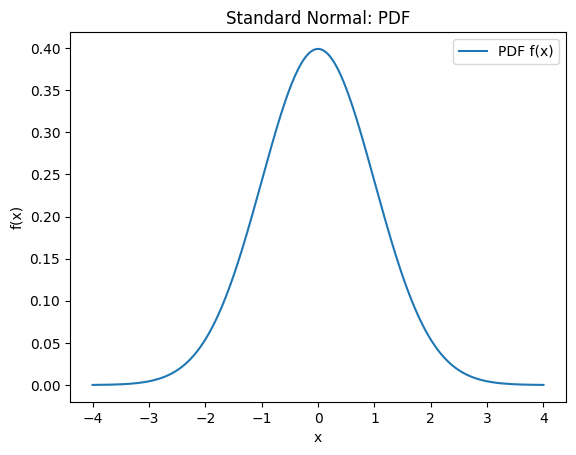

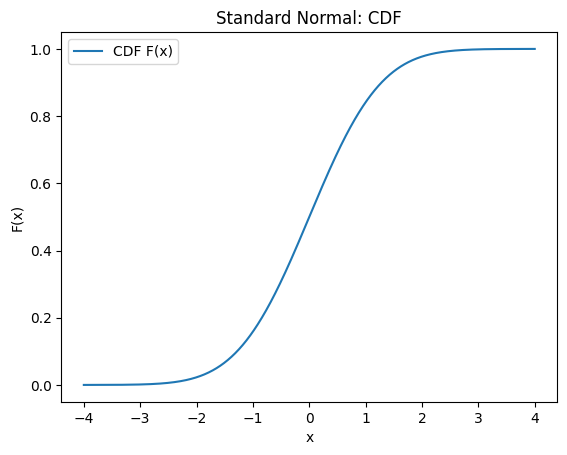

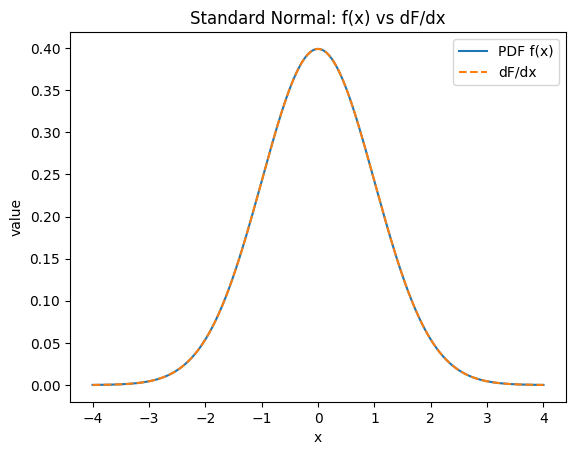

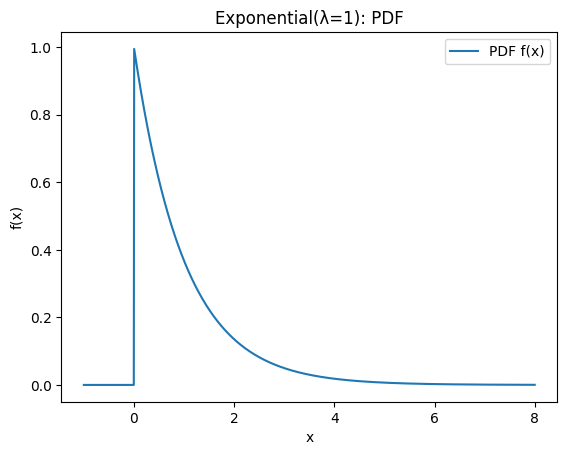

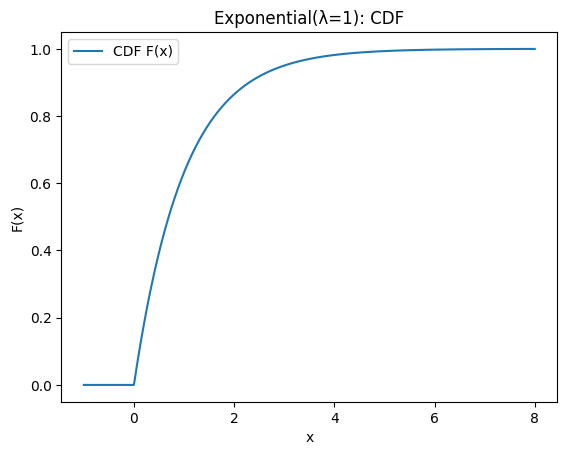

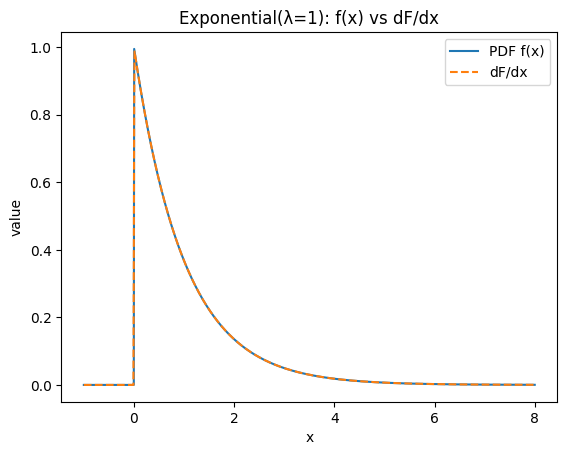

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def _erf_approx(x):
    sign = np.sign(x)
    x = np.abs(x)
    t = 1.0/(1.0+0.3275911*x)
    a1,a2,a3,a4,a5 = 0.254829592,-0.284496736,1.421413741,-1.453152027,1.061405429
    y = 1.0 - (((((a5*t + a4)*t) + a3)*t + a2)*t + a1)*t*np.exp(-x*x)
    return sign*y

def normal_pdf(x, mu=0.0, sigma=1.0):
    return (1.0/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

def normal_cdf(x, mu=0.0, sigma=1.0):
    z = (x-mu)/(sigma*np.sqrt(2.0))
    return 0.5*(1.0+_erf_approx(z))

def exp_pdf(x, lam=1.0):
    y = np.zeros_like(x); m = x>=0; y[m] = lam*np.exp(-lam*x[m]); return y

def exp_cdf(x, lam=1.0):
    y = np.zeros_like(x); m = x>=0; y[m] = 1.0-np.exp(-lam*x[m]); return y

def show_distribution(x, pdf, cdf, title):
    f = pdf(x); F = cdf(x); dF = np.gradient(F, x)
    plt.figure(); plt.plot(x, f, label="PDF f(x)"); plt.title(f"{title}: PDF"); plt.xlabel("x"); plt.ylabel("f(x)"); plt.legend(); plt.show()
    plt.figure(); plt.plot(x, F, label="CDF F(x)"); plt.title(f"{title}: CDF"); plt.xlabel("x"); plt.ylabel("F(x)"); plt.legend(); plt.show()
    plt.figure(); plt.plot(x, f, label="PDF f(x)"); plt.plot(x, dF, "--", label="dF/dx"); plt.title(f"{title}: f(x) vs dF/dx"); plt.xlabel("x"); plt.ylabel("value"); plt.legend(); plt.show()

x_norm = np.linspace(-4, 4, 1201)
x_exp  = np.linspace(-1, 8, 1201)

show_distribution(x_norm, normal_pdf, normal_cdf, "Standard Normal")
show_distribution(x_exp,  lambda x: exp_pdf(x, lam=1.0), lambda x: exp_cdf(x, lam=1.0), "Exponential(λ=1)")
